In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load prepared data
X_train = pd.read_csv(r'C:\Users\gulna\demand-forecasting-cloud\data\prepared\X_train.csv')
X_val = pd.read_csv(r'C:\Users\gulna\demand-forecasting-cloud\data\prepared\X_val.csv')
X_test = pd.read_csv(r'C:\Users\gulna\demand-forecasting-cloud\data\prepared\X_test.csv')

y_train = pd.read_csv(r'C:\Users\gulna\demand-forecasting-cloud\data\prepared\y_train.csv')
y_val = pd.read_csv(r'C:\Users\gulna\demand-forecasting-cloud\data\prepared\y_val.csv')
y_test = pd.read_csv(r'C:\Users\gulna\demand-forecasting-cloud\data\prepared\y_test.csv')

print(f" Loaded prepared datasets")
print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val: X={X_val.shape}, y={y_val.shape}")
print(f"Test: X={X_test.shape}, y={y_test.shape}")

 Loaded prepared datasets
Train: X=(60000, 76), y=(60000, 1)
Val: X=(20000, 76), y=(20000, 1)
Test: X=(20000, 76), y=(20000, 1)


In [4]:
print("\n" + "="*70)
print("DATA QUALITY VERIFICATION")
print("="*70)

print(f"\nMissing values:")
print(f"  Train: {X_train.isnull().sum().sum()}")
print(f"  Val: {X_val.isnull().sum().sum()}")
print(f"  Test: {X_test.isnull().sum().sum()}")

print(f"\nData shape consistency:")
print(f"  Features: {X_train.shape[1]} (same across all sets ✓)")

print(f"\nTarget distribution:")
print(f"  Train - Mean: ${y_train.values.mean():.2f}, Std: ${y_train.values.std():.2f}")
print(f"  Val - Mean: ${y_val.values.mean():.2f}, Std: ${y_val.values.std():.2f}")
print(f"  Test - Mean: ${y_test.values.mean():.2f}, Std: ${y_test.values.std():.2f}")

print(f"\n  Data ready for modeling.")


DATA QUALITY VERIFICATION

Missing values:
  Train: 0
  Val: 0
  Test: 0

Data shape consistency:
  Features: 76 (same across all sets ✓)

Target distribution:
  Train - Mean: $6115.59, Std: $3670.84
  Val - Mean: $5623.11, Std: $4249.71
  Test - Mean: $6017.31, Std: $4032.44

  Data ready for modeling.


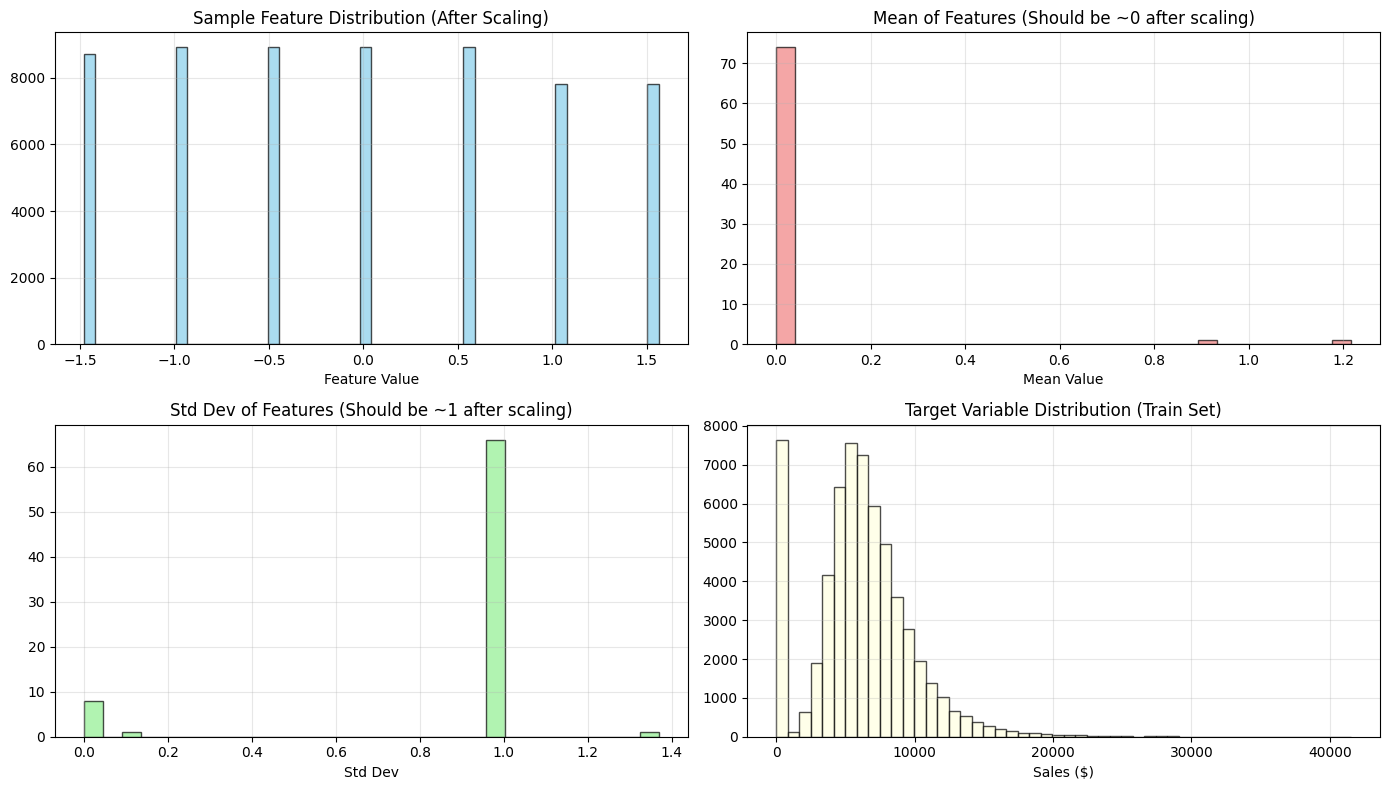

 Saved: 15_scaling_verification.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Feature value distribution
axes[0, 0].hist(X_train.iloc[:, 0].values, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Sample Feature Distribution (After Scaling)')
axes[0, 0].set_xlabel('Feature Value')
axes[0, 0].grid(True, alpha=0.3)

# Mean values across features
feature_means = X_train.mean()
axes[0, 1].hist(feature_means, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_title('Mean of Features (Should be ~0 after scaling)')
axes[0, 1].set_xlabel('Mean Value')
axes[0, 1].grid(True, alpha=0.3)

# Std values across features
feature_stds = X_train.std()
axes[1, 0].hist(feature_stds, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_title('Std Dev of Features (Should be ~1 after scaling)')
axes[1, 0].set_xlabel('Std Dev')
axes[1, 0].grid(True, alpha=0.3)

# Target distribution
axes[1, 1].hist(y_train.values, bins=50, edgecolor='black', alpha=0.7, color='lightyellow')
axes[1, 1].set_title('Target Variable Distribution (Train Set)')
axes[1, 1].set_xlabel('Sales ($)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\15_scaling_verification.png', dpi=100, bbox_inches='tight')
plt.show()

print(f" Saved: 15_scaling_verification.png")

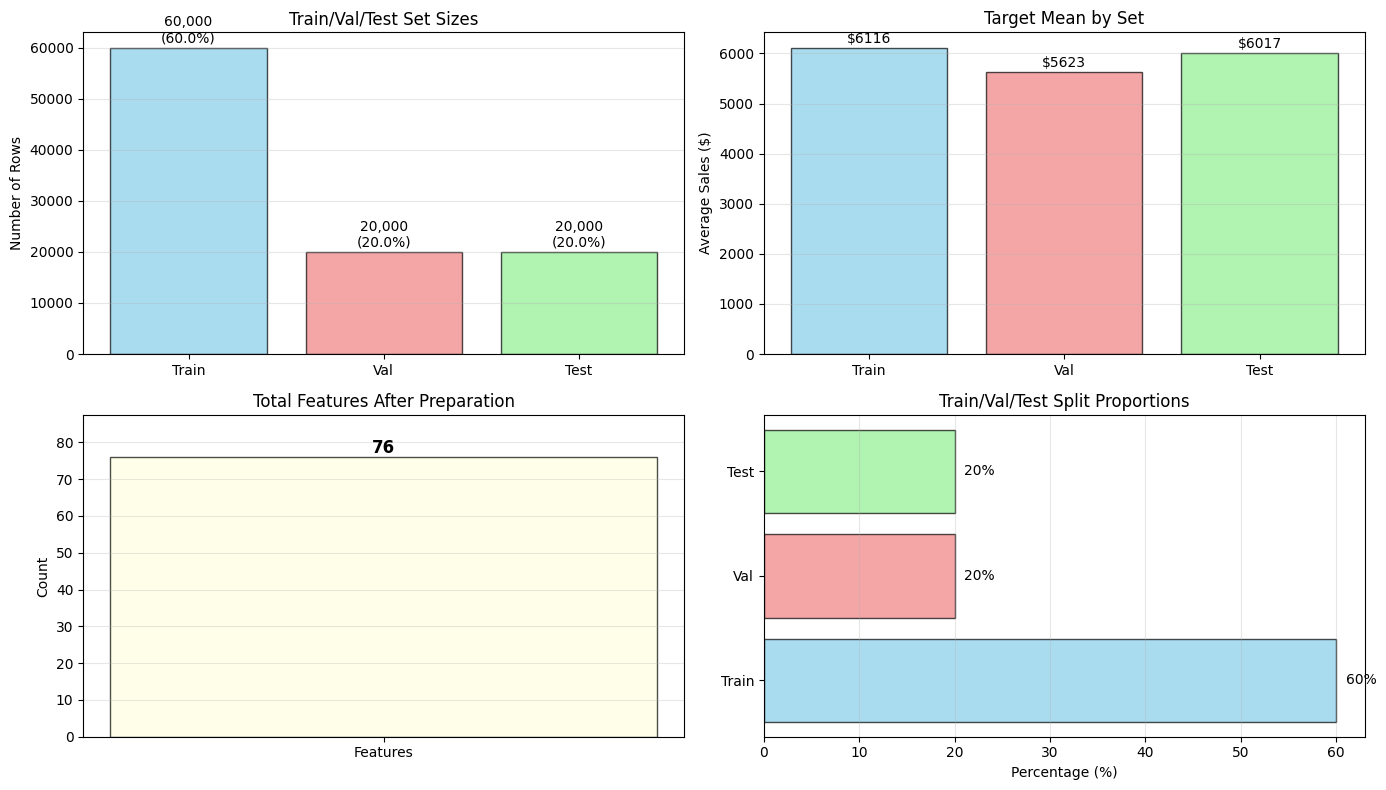

 Saved: 16_split_analysis.png

Split Summary:
  Train: 60,000 rows (60%)
  Val: 20,000 rows (20%)
  Test: 20,000 rows (20%)
  Features: 76


In [7]:
# Cell 4: Train/Val/Test split visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Set sizes
sets = ['Train', 'Val', 'Test']
sizes = [len(X_train), len(X_val), len(X_test)]
colors = ['skyblue', 'lightcoral', 'lightgreen']

axes[0, 0].bar(sets, sizes, color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Number of Rows')
axes[0, 0].set_title('Train/Val/Test Set Sizes')
axes[0, 0].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(sizes):
    axes[0, 0].text(i, v + 1000, f'{v:,}\n({v/sum(sizes)*100:.1f}%)', ha='center', fontsize=10)

# 2. Target distribution - simple bar chart
target_means = [y_train['Sales'].mean(),y_val['Sales'].mean(),y_test['Sales'].mean()]
axes[0, 1].bar(sets, target_means, color=colors, edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('Average Sales ($)')
axes[0, 1].set_title('Target Mean by Set')
axes[0, 1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(target_means):
    axes[0, 1].text(i, v + 100, f'${v:.0f}', ha='center', fontsize=10)

# 3. Feature count
n_features = X_train.shape[1]
axes[1, 0].bar(['Features'], [n_features], color='lightyellow', edgecolor='black', alpha=0.7, width=0.3)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title(f'Total Features After Preparation')
axes[1, 0].text(0, n_features + 1, f'{n_features}', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim([0, n_features * 1.15])
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Data timeline percentages
axes[1, 1].barh(['Train', 'Val', 'Test'], [60, 20, 20], color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Percentage (%)')
axes[1, 1].set_title('Train/Val/Test Split Proportions')
axes[1, 1].grid(True, alpha=0.3, axis='x')

for i, v in enumerate([60, 20, 20]):
    axes[1, 1].text(v + 1, i, f'{v}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\16_split_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f" Saved: 16_split_analysis.png")
print(f"\nSplit Summary:")
print(f"  Train: {len(X_train):,} rows (60%)")
print(f"  Val: {len(X_val):,} rows (20%)")
print(f"  Test: {len(X_test):,} rows (20%)")
print(f"  Features: {n_features}")

In [9]:
# Summary
print("\n" + "="*70)
print("DAY 4: DATA PREPARATION - COMPLETE!")
print("="*70)

print(f"\nDatasets Created:")
print(f"   X_train.csv ({len(X_train)} rows × {X_train.shape[1]} features)")
print(f"   X_val.csv ({len(X_val)} rows × {X_val.shape[1]} features)")
print(f"   X_test.csv ({len(X_test)} rows × {X_test.shape[1]} features)")
print(f"   y_train.csv, y_val.csv, y_test.csv")

print(f"\nProcessing Done:")
print(f"   Categorical encoding (LabelEncoder)")
print(f"   Numerical scaling (StandardScaler)")
print(f"   Temporal train/val/test split (no data leakage)")
print(f"   Preprocessing objects saved (scaler, encoders)")



DAY 4: DATA PREPARATION - COMPLETE!

Datasets Created:
   X_train.csv (60000 rows × 76 features)
   X_val.csv (20000 rows × 76 features)
   X_test.csv (20000 rows × 76 features)
   y_train.csv, y_val.csv, y_test.csv

Processing Done:
   Categorical encoding (LabelEncoder)
   Numerical scaling (StandardScaler)
   Temporal train/val/test split (no data leakage)
   Preprocessing objects saved (scaler, encoders)

Ready for Day 5:
   All features prepared
   All datasets split
   Ready for ML models
